# Student Performance Analysis

### Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

### Loading Dataset

In [4]:
df = pd.read_csv(r"C:\Users\yugan\Downloads\archive (3)\StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print(df.shape)

print(df.info())

print(df.describe())

(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000  

### Data Cleaning

In [6]:
### missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
### duplicates
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
## Rename Columns
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Numpy Operations

In [9]:
## Average Scores
math_mean = np.mean(df['math_score'])

reading_mean = np.mean(df['reading_score'])

writing_mean = np.mean(df['writing_score'])

print(math_mean)
print(reading_mean)
print(writing_mean)

66.089
69.169
68.054


In [10]:
## standard deviation
np.std(df['math_score'])

15.155496659628165

In [11]:
## maximum score
np.max(df['math_score'])

100

### Feature Engineering

In [12]:
df['average_score'] = (
    df['math_score']
    + df['reading_score']
    + df['writing_score']
)/3

In [13]:
df['performance'] = np.where(
    df['average_score'] >= 70,
    'Good',
    'Needs Improvement'
)

In [14]:
def grade(score):

    if score >= 90:
        return 'A'

    elif score >= 80:
        return 'B'

    elif score >= 70:
        return 'C'

    elif score >= 60:
        return 'D'

    else:
        return 'F'

df['grade'] = df['average_score'].apply(grade)

### EDA

In [15]:
df.groupby('gender')['average_score'].mean()

gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64

In [16]:
df.groupby(
    'parental_level_of_education'
)['average_score'].mean().sort_values(
    ascending=False
)

parental_level_of_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64

In [17]:
df.groupby(
    'test_preparation_course'
)['average_score'].mean()

test_preparation_course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64

## Group By

In [18]:
grouped = df.groupby('gender').agg({
    'math_score':'mean',
    'reading_score':'mean',
    'writing_score':'mean'
})

grouped

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


## Pivot Table

In [19]:
pivot = pd.pivot_table(
    df,
    values='average_score',
    index='gender',
    columns='test_preparation_course',
    aggfunc='mean'
)

pivot

test_preparation_course,completed,none
gender,,
female,74.454710,66.878244
male,70.781609,63.044372


In [20]:
student_info = df[
    ['gender',
     'parental_level_of_education']
]

scores = df[
    ['math_score',
     'reading_score',
     'writing_score']
]

In [21]:
student_info = student_info.reset_index()
scores = scores.reset_index()

In [22]:
merged_df = pd.merge(
    student_info,
    scores,
    on='index'
)

merged_df.head()

,index,gender,parental_level_of_education,math_score,reading_score,writing_score
0,0,female,bachelor's degree,72,72,74
1,1,female,some college,69,90,88
2,2,female,master's degree,90,95,93
3,3,male,associate's degree,47,57,44
4,4,male,some college,76,78,75


## Visualizations

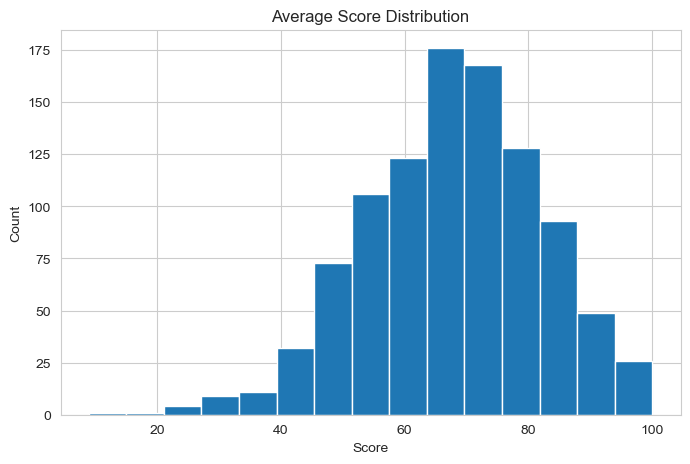

In [23]:
## histogram
plt.figure(figsize=(8,5))

plt.hist(
    df['average_score'],
    bins=15
)

plt.title("Average Score Distribution")

plt.xlabel("Score")

plt.ylabel("Count")

plt.show()

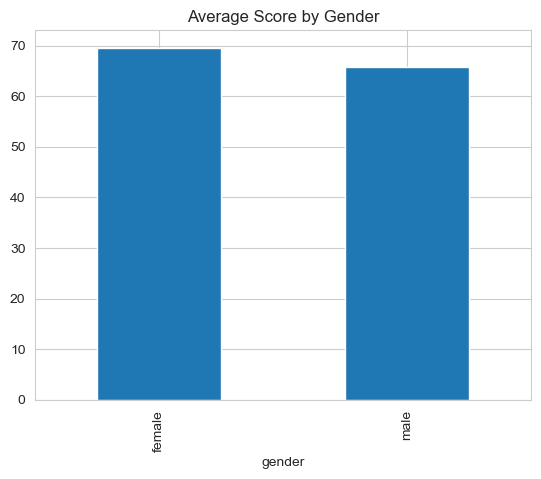

In [26]:
## bar chart
gender_avg = df.groupby(
    'gender'
)['average_score'].mean()

gender_avg.plot(
    kind='bar'
)

plt.title(
    "Average Score by Gender"
)

plt.show()

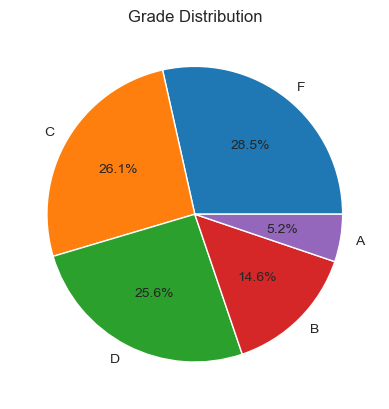

In [27]:
## pie chart
df['grade'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Grade Distribution")

plt.show()

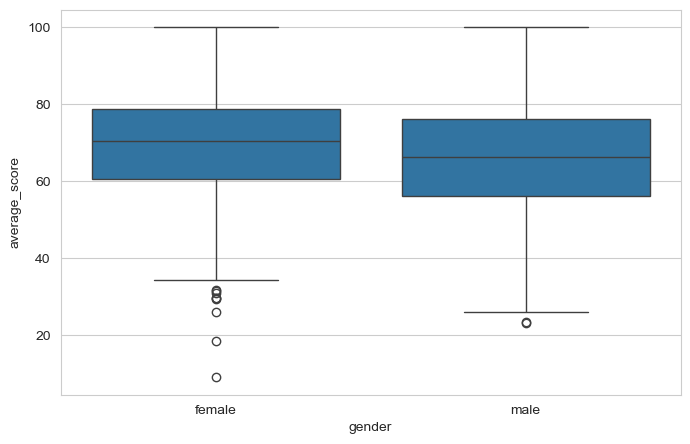

In [28]:
## boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='gender',
    y='average_score',
    data=df
)

plt.show()

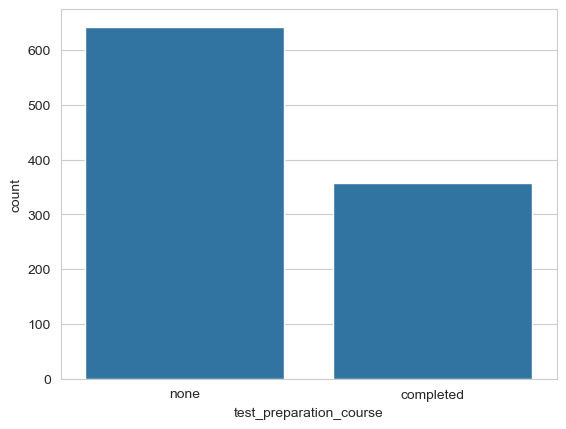

In [29]:
## countplot
sns.countplot(
    x='test_preparation_course',
    data=df
)

plt.show()

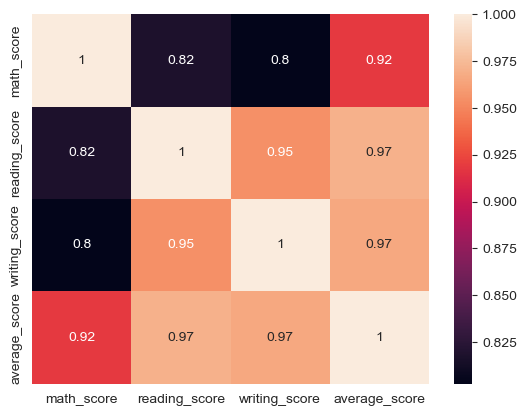

In [30]:
## heatmap
corr = df[
    ['math_score',
     'reading_score',
     'writing_score',
     'average_score']
].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()

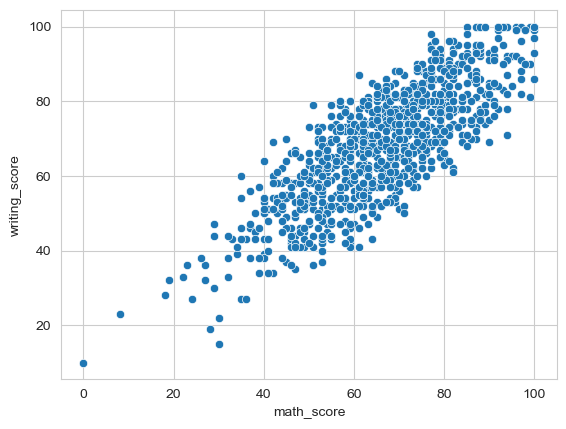

In [31]:
## scatter plot
sns.scatterplot(
    x='math_score',
    y='writing_score',
    data=df
)

plt.show()